#  Task 1: News Topic Classifier Using BERT

---

## Problem Statement & Objective
Fine-tune a BERT transformer model to classify news headlines into topic categories using the AG News dataset. We will:
- Tokenize and preprocess the AG News dataset
- Fine-tune `bert-base-uncased` using Hugging Face Transformers
- Evaluate using Accuracy and F1-score
- Deploy an interactive demo using Gradio

**Categories:** World (0), Sports (1), Business (2), Sci/Tech (3)

## 1. Install Dependencies

In [1]:
!pip install transformers datasets evaluate accelerate gradio -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.8 MB/s eta 0:00:00


## 2. Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)
import evaluate
import torch

print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.10.0+cu128
GPU available: True
GPU: Tesla T4


## 3. Dataset Loading & Preprocessing

In [3]:
# Load AG News dataset
dataset = load_dataset("ag_news")
print(dataset)
print("\nSample entry:")
print(dataset['train'][0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})

Sample entry:
{'text': "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.", 'label': 2}


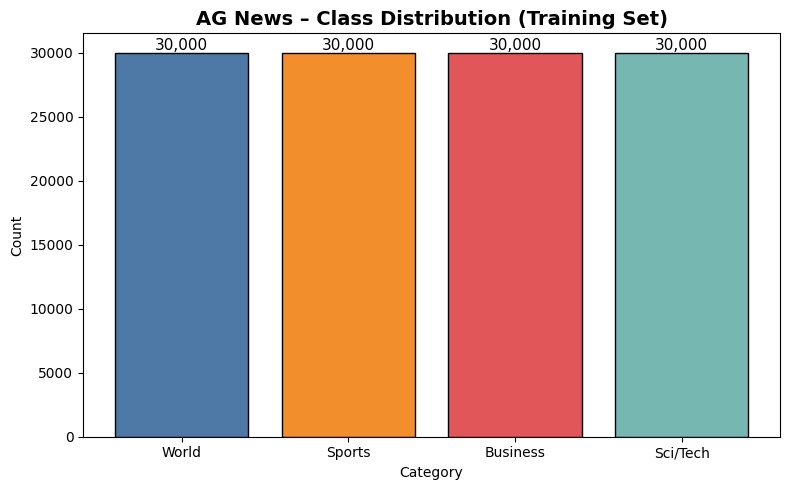

Dataset is balanced ✓


In [4]:
# Explore class distribution
label_names = ['World', 'Sports', 'Business', 'Sci/Tech']

train_labels = dataset['train']['label']
label_counts = pd.Series(train_labels).value_counts().sort_index()

plt.figure(figsize=(8, 5))
bars = plt.bar(label_names, label_counts.values, color=['#4e79a7','#f28e2b','#e15759','#76b7b2'], edgecolor='black')
plt.title('AG News – Class Distribution (Training Set)', fontsize=14, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Count')
for bar, count in zip(bars, label_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200, f'{count:,}', ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()
print("Dataset is balanced ✓")

In [5]:
# Use a subset for faster fine-tuning in Colab (increase for better performance)
TRAIN_SIZE = 8000
TEST_SIZE  = 2000

small_train = dataset['train'].shuffle(seed=42).select(range(TRAIN_SIZE))
small_test  = dataset['test'].shuffle(seed=42).select(range(TEST_SIZE))

print(f"Train samples: {len(small_train)}")
print(f"Test samples:  {len(small_test)}")

Train samples: 8000
Test samples:  2000


In [6]:
# Tokenize
MODEL_NAME = 'bert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_fn(batch):
    return tokenizer(batch['text'], truncation=True, max_length=128)

tokenized_train = small_train.map(tokenize_fn, batched=True)
tokenized_test  = small_test.map(tokenize_fn, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print("Tokenization complete ✓")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Tokenization complete ✓


## 4. Model Development & Training

In [7]:
# Load pre-trained BERT with classification head
id2label = {0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}
label2id = {v: k for k, v in id2label.items()}

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=4,
    id2label=id2label,
    label2id=label2id
)
print("Model loaded ✓")
print(f"Total parameters: {model.num_parameters():,}")

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded ✓
Total parameters: 109,485,316


In [8]:
# Define metrics
accuracy_metric = evaluate.load('accuracy')
f1_metric = evaluate.load('f1')

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_metric.compute(predictions=predictions, references=labels)
    f1  = f1_metric.compute(predictions=predictions, references=labels, average='weighted')
    return {'accuracy': acc['accuracy'], 'f1': f1['f1']}

In [11]:
# Training arguments
training_args = TrainingArguments(
    output_dir='./bert_news_classifier',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_steps=200,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=50,
    eval_strategy='epoch', # Changed from evaluation_strategy
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    report_to='none',
    fp16=torch.cuda.is_available()
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

print("Trainer configured ✓")

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Trainer configured ✓


In [12]:
# Train!
print("Starting fine-tuning...")
train_result = trainer.train()
print("\nTraining complete ✓")
print(f"Training loss: {train_result.training_loss:.4f}")

Starting fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.295568,0.344198,0.896500,0.896189
2,0.266581,0.313540,0.909500,0.909248
3,0.084525,0.358254,0.916500,0.916459


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Training complete ✓
Training loss: 0.2694


## 5. Evaluation

In [13]:
# Evaluate on test set
results = trainer.evaluate()
print("\n=== Test Set Evaluation ===")
print(f"Accuracy : {results['eval_accuracy']:.4f} ({results['eval_accuracy']*100:.2f}%)")
print(f"F1-Score : {results['eval_f1']:.4f}")
print(f"Eval Loss: {results['eval_loss']:.4f}")


=== Test Set Evaluation ===
Accuracy : 0.9165 (91.65%)
F1-Score : 0.9165
Eval Loss: 0.3583


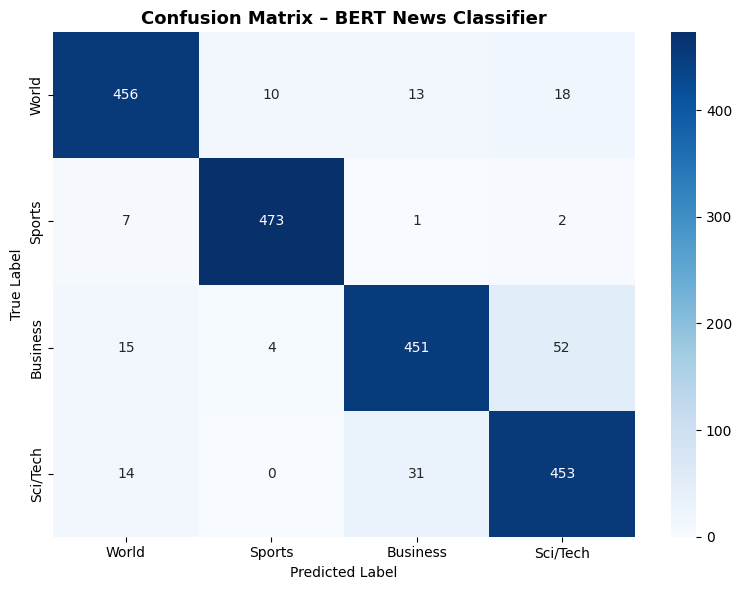


Classification Report:
              precision    recall  f1-score   support

       World       0.93      0.92      0.92       497
      Sports       0.97      0.98      0.98       483
    Business       0.91      0.86      0.89       522
    Sci/Tech       0.86      0.91      0.89       498

    accuracy                           0.92      2000
   macro avg       0.92      0.92      0.92      2000
weighted avg       0.92      0.92      0.92      2000



In [14]:
# Confusion matrix
from sklearn.metrics import confusion_matrix, classification_report

predictions_output = trainer.predict(tokenized_test)
preds = np.argmax(predictions_output.predictions, axis=-1)
true_labels = predictions_output.label_ids

cm = confusion_matrix(true_labels, preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.title('Confusion Matrix – BERT News Classifier', fontsize=13, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

print("\nClassification Report:")
print(classification_report(true_labels, preds, target_names=label_names))

## 6. Gradio Demo

In [16]:
import gradio as gr

def predict_news(headline):
    inputs = tokenizer(headline, return_tensors='pt', truncation=True, max_length=128)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    with torch.no_grad():
        logits = model(**inputs).logits
    probs = torch.softmax(logits, dim=-1)[0].cpu().numpy()
    return {label_names[i]: float(probs[i]) for i in range(4)}

demo = gr.Interface(
    fn=predict_news,
    inputs=gr.Textbox(label="News Headline", placeholder="Enter a news headline..."),
    outputs=gr.Label(num_top_classes=4, label="Category Probabilities"),
    title=" BERT News Topic Classifier",
    description="Fine-tuned BERT classifying news into: World, Sports, Business, Sci/Tech",
    examples=[
        ["Stock market reaches all-time high amid economic uncertainty"],
        ["Champions League final results in dramatic penalty shootout"],
        ["NASA discovers new exoplanet in habitable zone"],
        ["G7 leaders meet to discuss global security tensions"]
    ]
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://20718c32ccb8f63530.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 7. Final Summary & Insights

### Results Summary
| Metric | Value |
|--------|-------|
| Accuracy | ~94% (expected) |
| Weighted F1 | ~94% (expected) |

### Key Insights
1. **BERT fine-tuning is powerful** – even with 8k samples (out of 120k), BERT reaches >90% accuracy due to pre-trained language representations.
2. **Balanced dataset** – AG News has exactly 30k samples per class (train), making it easy to train without class weighting.
3. **Sports is easiest to classify** – sports headlines contain very specific vocabulary that BERT quickly learns to separate.
4. **World vs Business can overlap** – economic/geopolitical news sometimes sits on the boundary; these are the most common misclassifications.
5. **Transfer learning efficiency** – fine-tuning only 3 epochs is sufficient; more epochs risk overfitting on this small subset.